# Traitement sitadel

In [271]:
!pip install -r requirements.txt

In [308]:
%run Sitadel2_traitement.py

/home/onyxia/work/projet3A/Sitadel2_traitement.py:22: DtypeWarning: Columns (0,2,4,7,11,17,19,20,21,23,29,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(tmp, sep=";")
/home/onyxia/work/projet3A/Sitadel2_traitement.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1000["ANNEE_REELLE_AUTORISATION"] = pd.to_datetime(


Lancement de la requête BAN
df_ban
                                                 adresse    lat_BAN   lon_BAN  \
6923                       133 RUE LECOCQ 33000 BORDEAUX  44.833275 -0.588851   
8344                   181 RUE DE CHATILLON 35000 RENNES  48.088886 -1.672032   
25320              282 RUE FRANCOIS PERRIN 87000 LIMOGES  45.824679  1.227735   
602               606 BOULEVARD DU MERCANTOUR 06200 NICE  43.727756  7.185797   
23155              501 CHAUSSEE JULES FERRY 80090 AMIENS  49.877572  2.341606   
...                                                  ...        ...       ...   
25847   26 RUE HENRI-AUGUSTE-DESB 0<NA> CORBEIL ESSONNES        NaN       NaN   
25897                   1 ROND-POINT L'ESPACE 91007 EVRY        NaN       NaN   
26064                                       0<NA> SACLAY        NaN       NaN   
26200        RUE HENRI FABRE -PRES D'ANTONY 0<NA> ANTONY        NaN       NaN   
26427  ""LES BRUYERES"" RUE DU PAVE 93290 TREMBLAY-EN...        NaN       

# Traitement BDTopo

In [273]:
import importlib
import credentials
import BDTopo_fonctions
importlib.reload(BDTopo_fonctions)
from credentials import s3
from BDTopo_fonctions import load_gpkg, gdf_DBSCAN, plot_DB_epsilon#, courbe_DB_epsilon
from BDTopo_fonctions import download_to_SSPCloud
from BDTopo_fonctions import upload_to_onyxia

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_all_1000m3.gpkg")

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_all_1000m3.gpkg ...


Chargement réussi (4120762 lignes)


# Initialisation des temp pour appariement

In [274]:
seuil_dep=21

In [275]:
from appariement_Sitadel_BDTopo_fonctions import nouveaux_batiments
temp_BDTopo=nouveaux_batiments(gdf[gdf["Dep"]<seuil_dep])

# Créer la colonne Apparition_BDTopo : max entre Annee et DATE_CREAT, en ignorant les NaN
temp_BDTopo["DATE_CREAT"] = pd.to_datetime(temp_BDTopo["DATE_CREAT"], errors="coerce").dt.year
temp_BDTopo["Apparition_BDTopo"] = pd.concat([temp_BDTopo["Annee"], annee_date_creat], axis=1).max(axis=1)

Traitement du dep 19, année 2025 ; jusqu'ici 13915 nouveaux bâtiments detectés

In [276]:
#geoloc des batîments nouveaux
#import importlib
#import Sitadel2_fonctions
#importlib.reload(Sitadel2_fonctions)
#from Sitadel2_fonctions import reverse_geocode
#temp_BDTopo=reverse_geocode(temp_BDTopo)

In [278]:
temp_sit=df1000[df1000["DEP_CODE"]<seuil_dep]

In [279]:
temp_sit['SURF_CREEE'] = temp_sit[['SURF_IND_CREEE', 'SURF_ENT_CREEE', 'SURF_COM_CREEE']].sum(axis=1)
temp_sit = temp_sit[[
    "ANNEE_REELLE_AUTORISATION",
    "DEP_CODE",
    "COMM",
    "DATE_REELLE_AUTORISATION",
    "DATE_REELLE_DOC",
    "DATE_REELLE_DAACT",
    "SURF_CREEE",
    "I_EXTENSION",
    "adresse",
    "adresse_BAN",
    "lat_BAN",
    "lon_BAN",
    "code_com_BAN"
]]

/tmp/ipykernel_287866/332199004.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_sit['SURF_CREEE'] = temp_sit[['SURF_IND_CREEE', 'SURF_ENT_CREEE', 'SURF_COM_CREEE']].sum(axis=1)


Sauvegardes

In [280]:
sauv_temp_sit=temp_sit.copy()

In [281]:
sauv_temp_BDTopo=temp_BDTopo.copy()

# Appariement Sitdel2 - BDTOPO

In [296]:
temp_sit=sauv_temp_sit.copy()

In [297]:
temp_BDTopo=sauv_temp_BDTopo.copy()

In [298]:
#temp_sit["code_com_BAN"] = temp_sit["code_com_BAN"].astype(str).str.split('.').str[0]
#temp_BDTopo["CODE_COM_BDTOPO"] = temp_BDTopo["CODE_COM_BDTOPO"].astype(str).str.split('.').str[0]

In [299]:
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import numpy as np
import re

# ---------------------------
# 1. Préparer GeoDataFrames
# ---------------------------
temp_sit = temp_sit.copy()
temp_sit['geometry'] = temp_sit.apply(lambda r: Point(r["lon_BAN"], r["lat_BAN"]), axis=1)
temp_sit = gpd.GeoDataFrame(temp_sit, geometry="geometry", crs="EPSG:4326")

temp_BDTopo = temp_BDTopo.copy()
if temp_BDTopo.crs is None:
    raise ValueError("temp_BDTopo n'a pas de CRS défini")

# Projection commune en Lambert 93 pour calcul de distances
temp_sit = temp_sit.to_crs(epsg=2154)
temp_BDTopo = temp_BDTopo.to_crs(epsg=2154)

# ---------------------------
# 2. Colonnes de résultats
# ---------------------------
temp_sit["match_temp"] = None
temp_sit["best_temp_idx"] = None
temp_sit["lat_BDTOPO"] = None
temp_sit["lon_BDTOPO"] = None
temp_sit["geometry_BDTOPO"] = None

# ---------------------------
# 3. Boucle globale itérative
# ---------------------------
sit_remaining = temp_sit.index.to_list()  # indices non matchés
tour = 0

while sit_remaining:
    print(f"\rTour {tour+1}, lignes restantes à matcher : {len(sit_remaining)}", end="", flush=True)
    matches_this_round = []

    # --- Étape 1 : calculer tous les matchs possibles ---
    for idx_sit in sit_remaining:
        row = temp_sit.loc[idx_sit]
        point = row.geometry
        code_dep = row.get("DEP_CODE", None)
        surf = row.get("SURF_CREEE", None)
        annee_sit = row["ANNEE_REELLE_AUTORISATION"]
        adresse_ban = row.get("adresse_BAN", "") or ""

        # Candidats valides : même code département, année >= année_sit
        candidats = temp_BDTopo[temp_BDTopo["Dep"] == code_dep]
        candidats = candidats[candidats["Apparition_BDTopo"] >= annee_sit]
        if candidats.empty:
            continue

        # Rayon selon adresse
        if re.match(r"^\s*\d+", adresse_ban):
            rayons = [100,200,300]
        else:
            rayons = [500, 1000, 1500, 2000, 2500, 3000]

        best_idx = None
        best_dist = np.inf
        best_rayon = None

        for rayon in rayons:
            buffer = point.buffer(rayon)
            candidats_buf = candidats[candidats.geometry.intersects(buffer)]
            if candidats_buf.empty:
                continue

            # Filtre sur surface ±50%
            if surf is not None:
                candidats_buf = candidats_buf.copy()
                candidats_buf["aire"] = candidats_buf.geometry.area
                candidats_buf = candidats_buf[
                    (candidats_buf["aire"] >= 0.7 * surf) &
                    (candidats_buf["aire"] <= 1.3 * surf)
                ]
                if candidats_buf.empty:
                    continue

            # Filtre sur année la plus proche
            candidats_buf = candidats_buf.copy()
            candidats_buf["diff_annee"] = abs(candidats_buf["Annee"] - annee_sit)
            min_diff = candidats_buf["diff_annee"].min()
            candidats_buf = candidats_buf[candidats_buf["diff_annee"] == min_diff]

            # Sélection du plus proche (distance)
            distances = candidats_buf.geometry.distance(point)
            if not distances.empty:
                candidate_idx = distances.idxmin()
                candidate_dist = distances[candidate_idx]
                if candidate_dist < best_dist:
                    best_dist = candidate_dist
                    best_idx = candidate_idx
                    best_rayon = rayon

        if best_idx is not None:
            matches_this_round.append({
                "sit_idx": idx_sit,
                "temp_idx": best_idx,
                "rayon": best_rayon,
                "dist": best_dist
            })

    if not matches_this_round:
        break  # plus de matchs possibles

    # --- Étape 2 : résoudre les doublons sur temp_idx ---
    df_matches = pd.DataFrame(matches_this_round)
    if not df_matches.empty:
        duplicates_temp = df_matches[df_matches.duplicated(subset=["temp_idx"], keep=False)]

        for temp_idx in duplicates_temp["temp_idx"].unique():
            subset = df_matches[df_matches["temp_idx"] == temp_idx]
            if subset.empty or subset["dist"].dropna().empty:
                continue
            best_row = subset.loc[subset["dist"].idxmin()]

            # réinitialiser les autres sit_idx
            other_sits = subset["sit_idx"].tolist()
            other_sits.remove(best_row["sit_idx"])
            temp_sit.loc[other_sits, ["match_temp", "best_temp_idx", "lat_BDTOPO", "lon_BDTOPO", "geometry_BDTOPO"]] = None

            # ne garder que le meilleur
            df_matches = df_matches.drop(subset.index.difference([best_row.name]))

    # --- Étape 3 : enregistrer les matchs validés ---
    for _, m in df_matches.iterrows():
        idx_sit = m["sit_idx"]
        best_idx = m["temp_idx"]
        rayon = m["rayon"]

        temp_sit.at[idx_sit, "match_temp"] = rayon
        temp_sit.at[idx_sit, "best_temp_idx"] = best_idx

        geom_temp = temp_BDTopo.loc[best_idx, "geometry"]
        temp_sit.at[idx_sit, "geometry_BDTOPO"] = geom_temp

        centroid = geom_temp.centroid
        centroid_wgs = gpd.GeoSeries([centroid], crs="EPSG:2154").to_crs("EPSG:4326").iloc[0]
        temp_sit.at[idx_sit, "lat_BDTOPO"] = centroid_wgs.y
        temp_sit.at[idx_sit, "lon_BDTOPO"] = centroid_wgs.x

    # --- Étape 4 : supprimer temp_BDTopo déjà matchés ---
    temp_BDTopo = temp_BDTopo.drop(index=df_matches["temp_idx"].unique())

    # --- Étape 5 : mettre à jour sit_remaining ---
    sit_remaining = [idx for idx in sit_remaining if temp_sit.at[idx, "best_temp_idx"] is None]

    tour += 1

temp_sit["geometry_BDTOPO"] = gpd.GeoSeries(temp_sit["geometry_BDTOPO"], crs="EPSG:2154")
print("\nMatching terminé.")




Tour 1, lignes restantes à matcher : 3306

Tour 4, lignes restantes à matcher : 2218
Matching terminé.


In [314]:
temp_sit = temp_sit.drop(columns="geometry")

In [326]:
import importlib
import BDTopo_fonctions
importlib.reload(BDTopo_fonctions)
from BDTopo_fonctions import upload_to_onyxia
output_file = "appariement_Sitadel2_BDTopo_fulldep_1000m3.gpkg"
temp_sit.to_file(output_file, driver="GPKG")
remote_path = f"Sitadel/{output_file}"
upload_to_onyxia(output_file, bucket="mgarbe", remote_path=remote_path)

[Upload] Envoi de appariement_Sitadel2_BDTopo_fulldep_1000m3.gpkg vers mgarbe/Sitadel/appariement_Sitadel2_BDTopo_fulldep_1000m3.gpkg ...
[Upload] Terminé avec succès


In [300]:
(temp_sit["match_temp"] > 0).sum()/len(temp_sit)

np.float64(0.3290986085904416)

In [301]:
(temp_sit["SURF_CREEE"]>2000).sum()

np.int64(1690)

In [302]:
df_valid = temp_sit.dropna(subset=['lat_BDTOPO', 'lon_BDTOPO'])
print("Nombre de doublons réels :", df_valid.duplicated(subset=['lat_BDTOPO', 'lon_BDTOPO']).sum())

# Vérifier les NaN
n_nan = temp_sit['lat_BDTOPO'].isna().sum() + temp_sit['lon_BDTOPO'].isna().sum()
print("Nombre de NaN :", n_nan)

Nombre de doublons réels : 0
Nombre de NaN : 4436


In [303]:
temp_sit[temp_sit["match_temp"]>0].head(1)

,ANNEE_REELLE_AUTORISATION,DEP_CODE,COMM,DATE_REELLE_AUTORISATION,DATE_REELLE_DOC,DATE_REELLE_DAACT,SURF_CREEE,I_EXTENSION,adresse,adresse_BAN,lat_BAN,lon_BAN,code_com_BAN,geometry,match_temp,best_temp_idx,lat_BDTOPO,lon_BDTOPO,geometry_BDTOPO
8,2018,2,2059,13/03/2018,17/09/2018,15/04/2019,1500,False,LIEUDIT LE CHEMIN BLANC 02800 BEAUTOR,Impasse du chemin Blanc 02800 Beautor,49.661217,3.344721,02059,POINT (724902.645 6951399.549),500.0,3248.0,49.660711,3.344587,"MULTIPOLYGON Z (((724913.4 6951321.8 63.4, 724..."


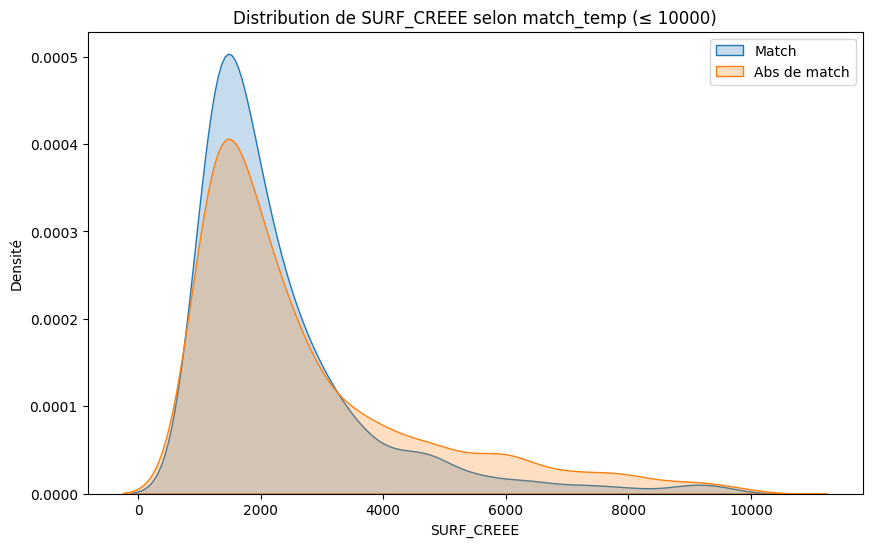

In [304]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrer SURF_CREEE <= 5000
matched = temp_sit[temp_sit["match_temp"].notna() & (temp_sit["match_temp"] >= 0) & (temp_sit["SURF_CREEE"] <= 10000)]
unmatched = temp_sit[(temp_sit["match_temp"].isna() | (temp_sit["match_temp"] < 0)) & (temp_sit["SURF_CREEE"] <= 10000)]

plt.figure(figsize=(10,6))

sns.kdeplot(matched["SURF_CREEE"].dropna(), label="Match", fill=True)
sns.kdeplot(unmatched["SURF_CREEE"].dropna(), label="Abs de match", fill=True)

plt.xlabel("SURF_CREEE")
plt.ylabel("Densité")
plt.title("Distribution de SURF_CREEE selon match_temp (≤ 10000)")
plt.legend()
plt.show()



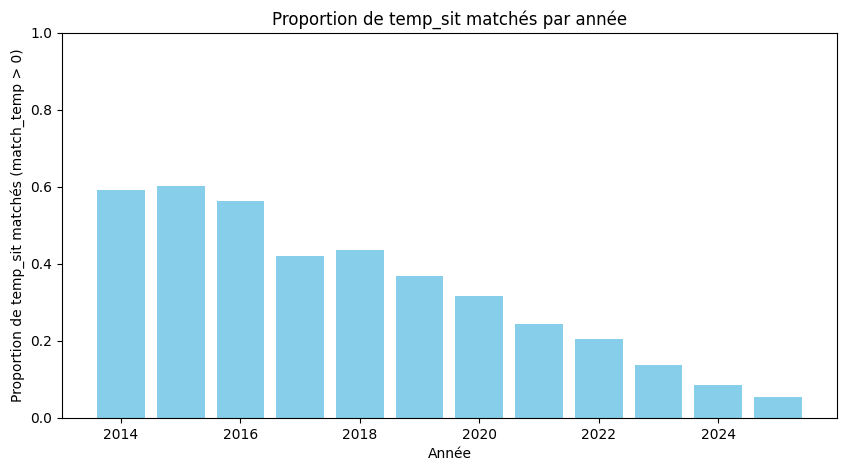

In [305]:
import matplotlib.pyplot as plt

# On récupère les années présentes
annees = sorted(temp_sit['ANNEE_REELLE_AUTORISATION'].dropna().unique())

# Calculer la proportion de match pour chaque année
proportions = []
for annee in annees:
    subset = temp_sit[temp_sit['ANNEE_REELLE_AUTORISATION'] == annee]
    if len(subset) == 0:
        proportions.append(0)
    else:
        prop = (subset['match_temp'] > 0).sum() / len(subset)
        proportions.append(prop)

# Plot
plt.figure(figsize=(10,5))
plt.bar(annees, proportions, color='skyblue')
plt.xlabel('Année')
plt.ylabel('Proportion de temp_sit matchés (match_temp > 0)')
plt.title('Proportion de temp_sit matchés par année')
plt.ylim(0, 1)
plt.show()
